<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 2, Baselines Modernos para Series de Tiempo**

Importamos lo necesario

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### **A) Dataset**


Creamos una serie de juguete (ventas trimestrales con patrón estacional)

In [ ]:
ventas = [82, 118, 138, 102,   88, 122, 145, 108,
          92, 128, 150, 112,   96, 132, 158, 118,
          100, 138, 162, 122,  105, 142, 168, 128,
          110, 148, 172, 132,  114, 152, 178, 138]

In [ ]:
ventas

[82,
 118,
 138,
 102,
 88,
 122,
 145,
 108,
 92,
 128,
 150,
 112,
 96,
 132,
 158,
 118,
 100,
 138,
 162,
 122,
 105,
 142,
 168,
 128,
 110,
 148,
 172,
 132,
 114,
 152,
 178,
 138]

Creamos un índice temporal trimestral desde 2017

In [ ]:
idx = pd.period_range("2017Q1", periods=len(ventas), freq="Q")

In [ ]:
idx

PeriodIndex(['2017Q1', '2017Q2', '2017Q3', '2017Q4', '2018Q1', '2018Q2',
             '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4',
             '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2',
             '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4',
             '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2',
             '2024Q3', '2024Q4'],
            dtype='period[Q-DEC]')

Convertimos la lista en serie temporal con índice trimestral

In [ ]:
serie = pd.Series(ventas, index=idx, name="ventas").astype(float)

In [ ]:
serie

,ventas
2017Q1,82.0
2017Q2,118.0
2017Q3,138.0
2017Q4,102.0
2018Q1,88.0
2018Q2,122.0
2018Q3,145.0
2018Q4,108.0
2019Q1,92.0
2019Q2,128.0


### **B) Split Temporal**

In [ ]:
H = 8 # número de pasos a predecir (2 años)
M = 4 # estacionalidad (4 trimestres por año)

Separamos pasado (train) y futuro (test)

In [ ]:
train, test = serie.iloc[:-H], serie.iloc[-H:]

In [ ]:
y_true = test.to_numpy() # valores reales del test
y = train.to_numpy() # valores de entrenamiento

In [ ]:
print(y_true)
print(y)

[110. 148. 172. 132. 114. 152. 178. 138.]
[ 82. 118. 138. 102.  88. 122. 145. 108.  92. 128. 150. 112.  96. 132.
 158. 118. 100. 138. 162. 122. 105. 142. 168. 128.]


### **B) Baselines**

In [ ]:
pred = {}

Repetimos el último valor observado

In [ ]:
pred["Naive"] = np.repeat(y[-1], H)

Usamos la media histórica como predicción constante

In [ ]:
pred["Media"] = np.repeat(y.mean(), H)

Repite el último patrón estacional de 4 trimestres

In [ ]:
pred["Seasonal naive"] = y[-M:][np.arange(H) % M]

Ajusta una recta (tendencia lineal) a la serie

In [ ]:
b1, b0 = np.polyfit(np.arange(len(y)), y, 1)

Extrapolamos la tendencia lineal hacia el futuro

In [ ]:
pred["Linear trend"] = b0 + b1 * np.arange(len(y), len(y) + H)

Proyectamos usando la pendiente promedio entre inicio y fin

In [ ]:
pred["Drift"] = y[-1] + np.arange(1, H + 1) * (y[-1] - y[0]) / (len(y) - 1)

### **C) Métricas de evaluación (MAE, RMSE, MAPE, MASE)**

In [ ]:
escala = np.mean(np.abs(y[M:] - y[:-M]))     # variacion año a año en train

Error promedio del naive estacional dentro del train (baseline MASE)

In [ ]:
filas = []

for nombre, p in pred.items():
    filas.append({
        "Modelo": nombre,
        "MAE": np.mean(np.abs(y_true - p)),                         # error absoluto medio
        "RMSE": np.sqrt(np.mean((y_true - p) ** 2)),               # penaliza errores grandes
        "MAPE": np.mean(np.abs((y_true - p) / y_true)) * 100,     # error porcentual
        "MASE": np.mean(np.abs(y_true - p)) / escala,              # error escalado vs naive
    })

Creamos tabla de resultados y ordenamos por mejor modelo

In [ ]:
tabla = pd.DataFrame(filas).set_index("Modelo").round(2).sort_values("MASE")
print(tabla)

                  MAE   RMSE   MAPE  MASE
Modelo                                   
Seasonal naive   7.25   7.70   5.16  1.41
Linear trend    19.50  22.49  14.43  3.79
Drift           19.50  22.83  13.45  3.79
Naive           23.00  27.50  15.24  4.47
Media           25.46  30.46  16.57  4.94


### **D) Visualización de resultados**

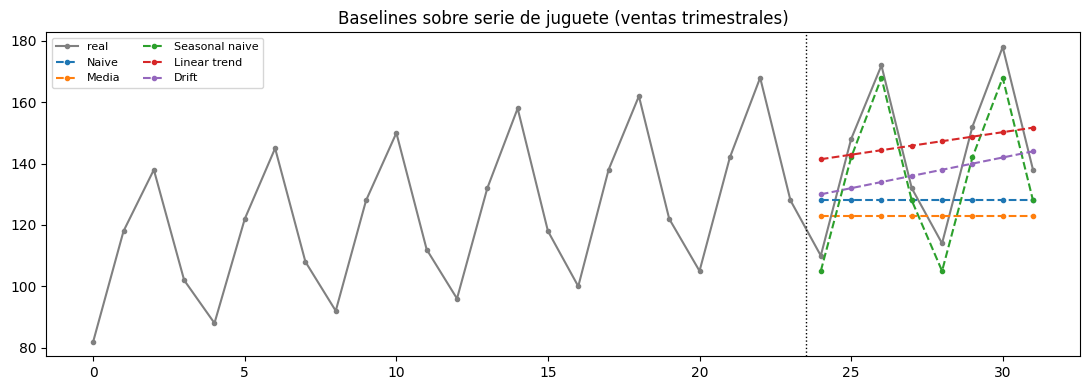

In [ ]:
x_hist = np.arange(len(serie)) # eje temporal completo
x_fut = np.arange(len(train), len(serie)) # solo futuro

plt.figure(figsize=(11, 4))

# Gráfica de la serie original
plt.plot(x_hist, serie.values, color="gray", marker="o", ms=3, label="real")


for nombre, p in pred.items():
    # cada modelo dibuja su predicción
    plt.plot(x_fut, p, ls="--", marker=".", label=nombre)

# separa visualmente train vs test
plt.axvline(len(train) - 0.5, color="k", ls=":", lw=1)

plt.title("Baselines sobre serie de juguete (ventas trimestrales)")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()